In [1]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../../..")

In [2]:
import pandas as pd

from tqdm import tqdm
from pathlib import Path

from ltr_utility.dataset import load_query_similarity, load_by_query_dataset, DatasetName
from ltr_utility.model_selection import evaluate, show_distr_conf, custom_train

from experiments.wrappers import *

In [3]:
base_path = Path("../../../datasets")
base_result = Path("results")
base_result.mkdir(parents=True, exist_ok=True)

In [4]:
eval_at = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25]
hold_out = (0.5, 0.2, 0.3)
iqr_trim = None  #(25, 75)
query_groups = load_query_similarity(Path("results"))

In [5]:
train, valid, test, train_valid = load_by_query_dataset(base_path, DatasetName.MQ2008LIST, max_item=100, hold_out=hold_out)

Loading train dataset from cache.
Train data loaded from cache.
Loading valid dataset from cache.
Valid data loaded from cache.
Loading test dataset from cache.
Test data loaded from cache.
---- MQ2007 2008 LIST loaded ----
Filtered out 0 queries with fewer than 10 documents.
---- discard_minority_groups 10 queries ----
---- Get first 500 queries ----
---- max_item 100 -(determistic!) ----
---- Update the listwise ranking target  ----
---- Holdout (0.5, 0.2, 0.3) - (determistic!) ----


# LambdaMART

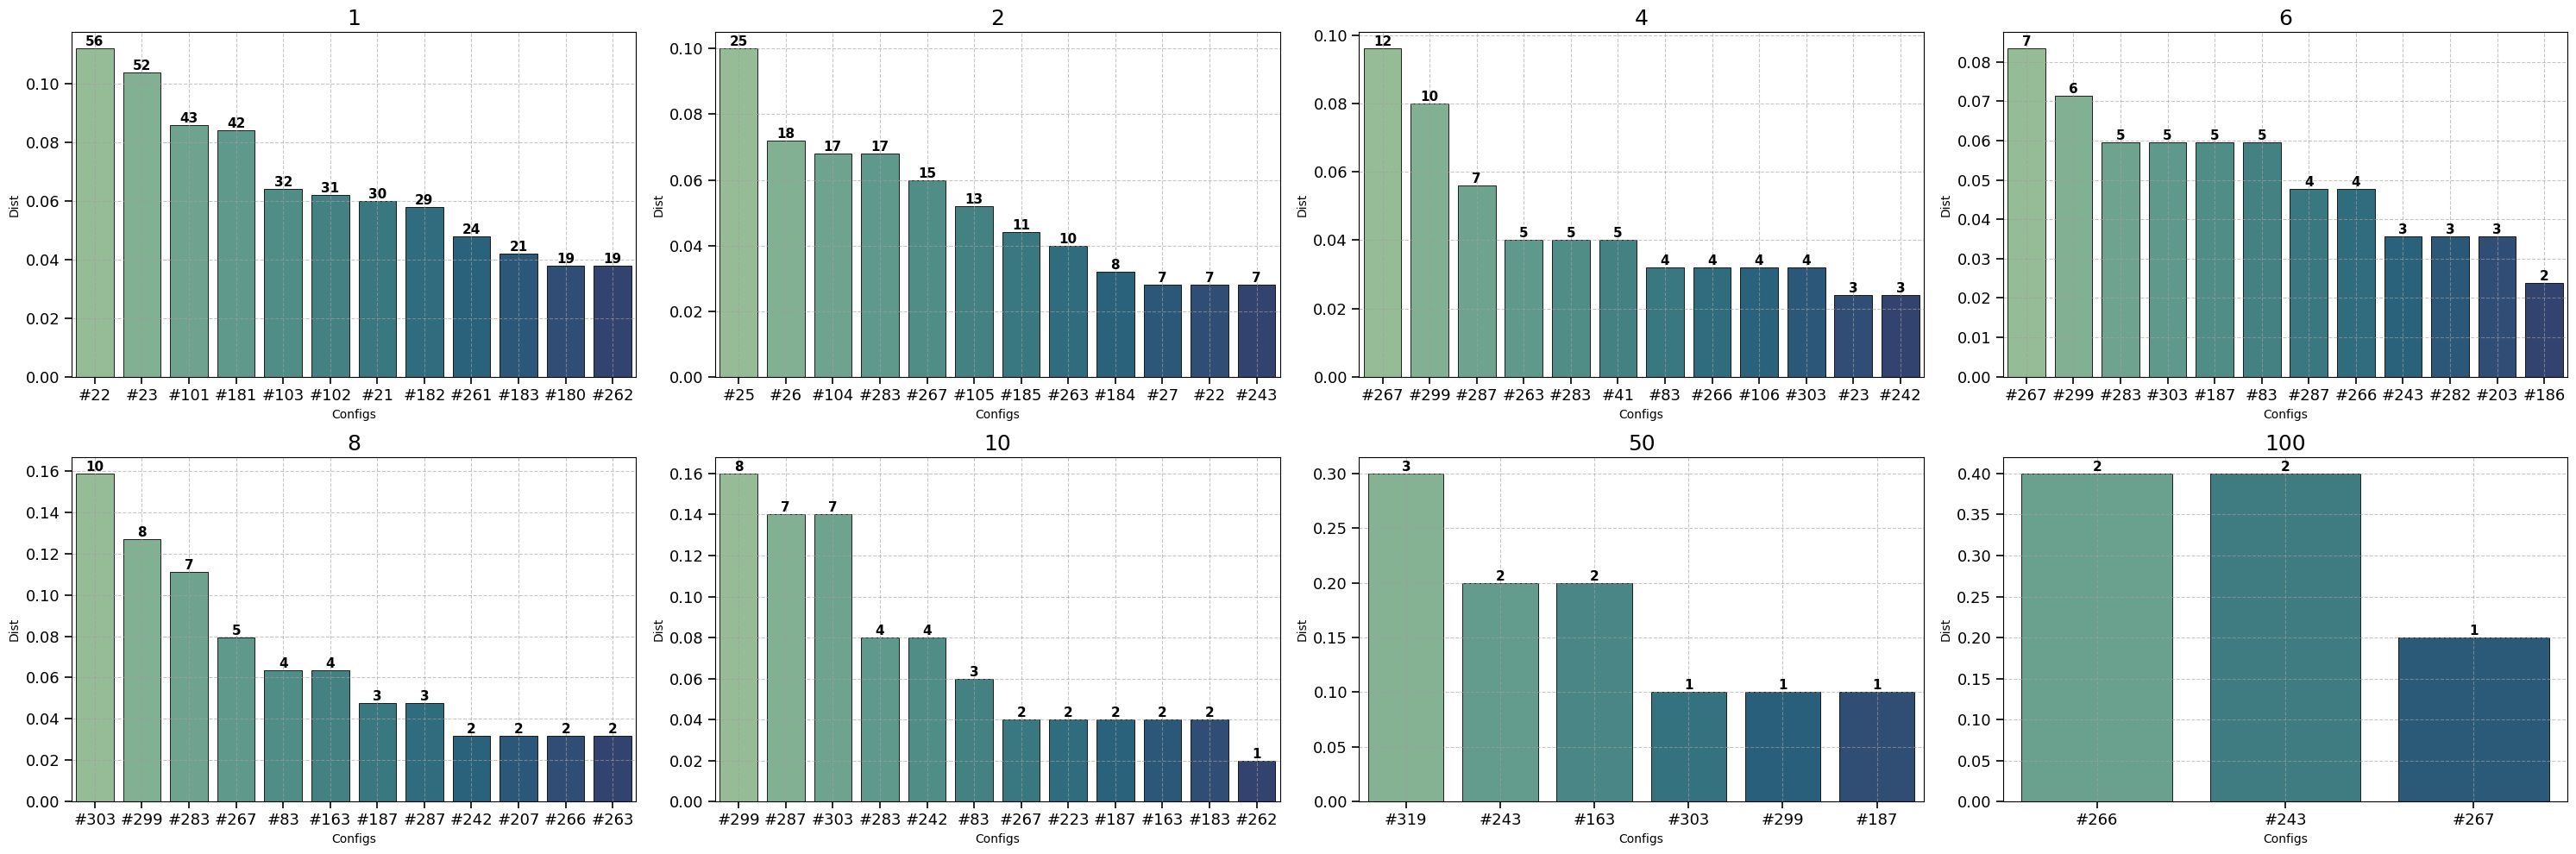

In [6]:
lm_ms = pd.read_json(base_result / "lm_query_model_selection.json")
lm_conf_dist = show_distr_conf(lm_ms)

In [14]:
lm_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:22, 2:25, 4:267, 6:267, 8:303, 10:299, 50:319, 100:266},
    "lm_query_model_selection.json",
    lm_ms,
    "LambdaMART",
    WrapperLGBMRanker
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:06<00:00, 72.69it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:02<00:00, 88.48it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:13<00:00,  3.61it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:18<00:00,  1.83s/it]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:02<00:00,  2.12it/s]


# KNN

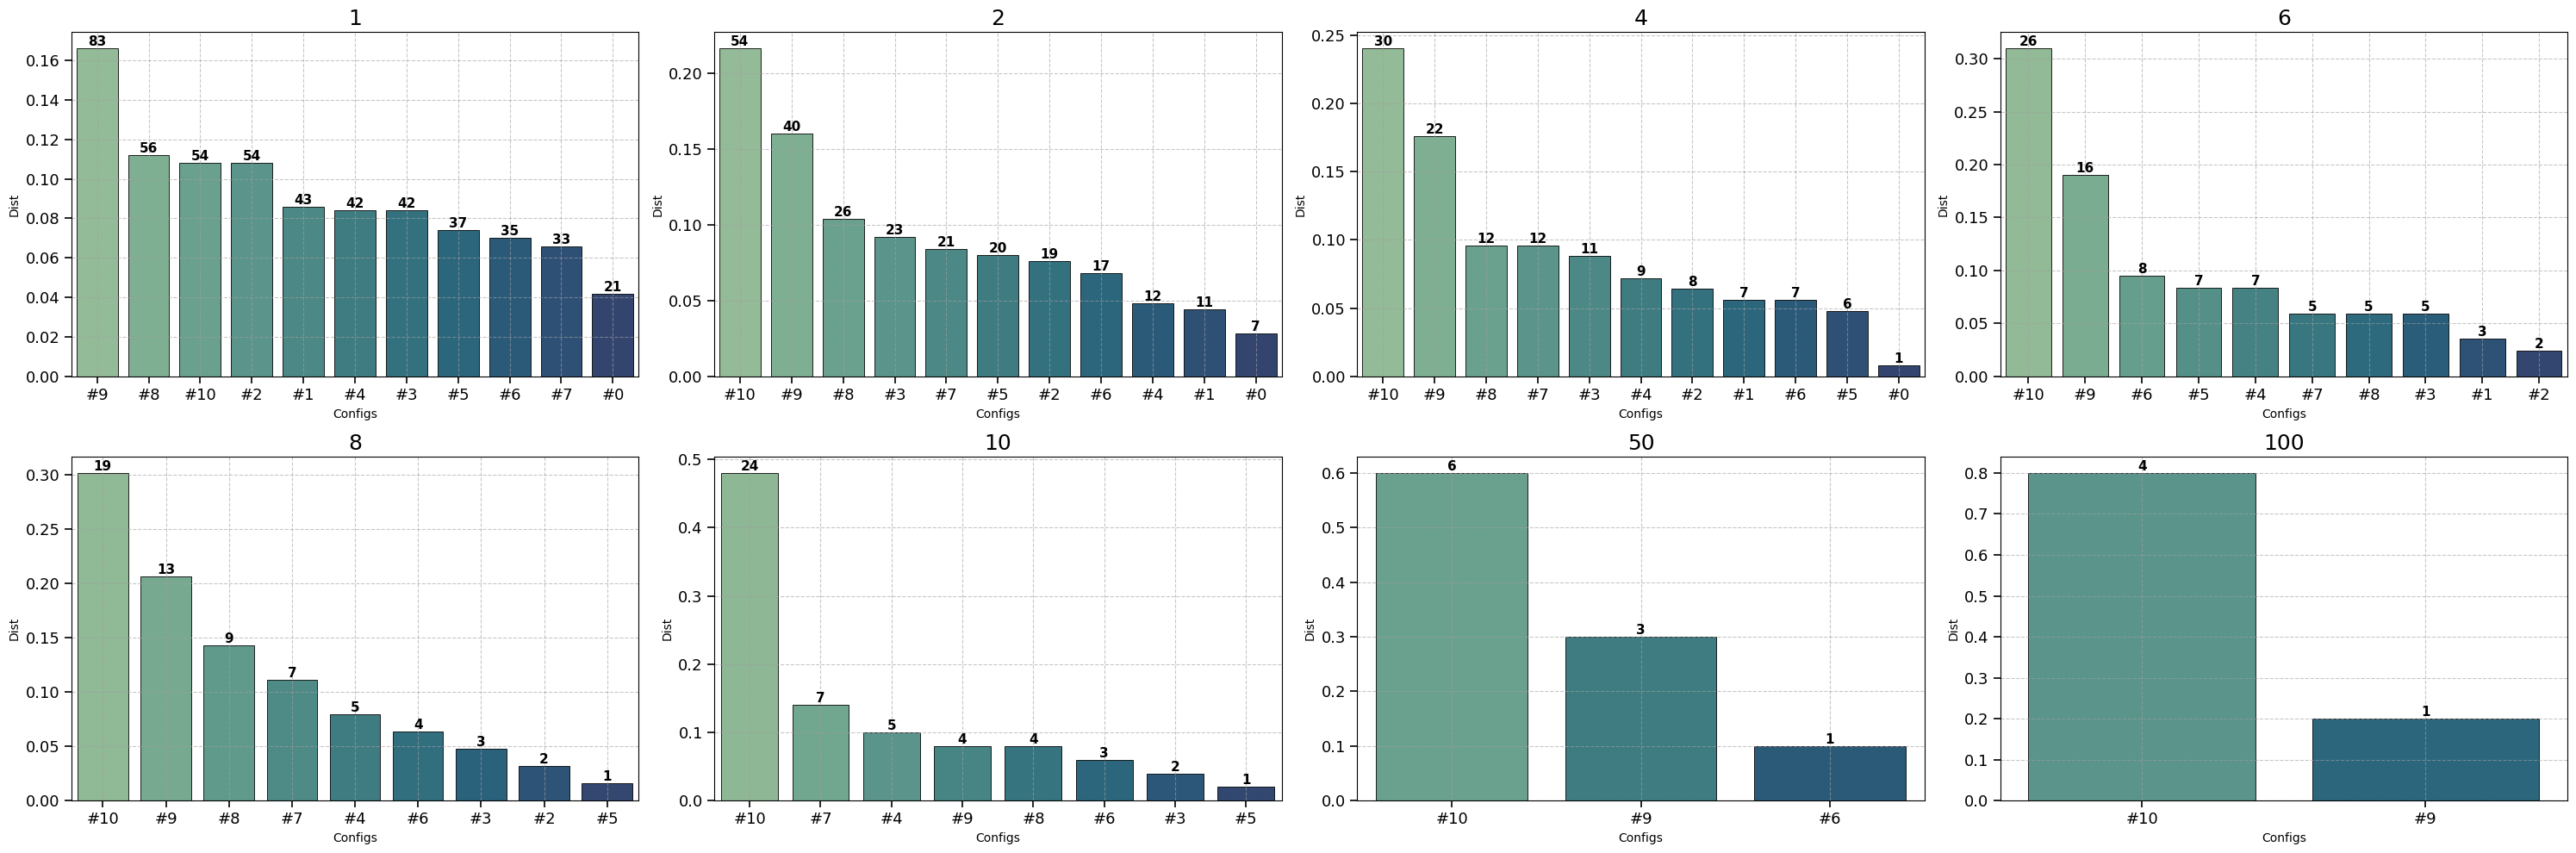

In [7]:
knn_ms = pd.read_json(base_result / "knn_query_model_selection.json")
knn_conf_dist = show_distr_conf(knn_ms)

In [15]:
knn_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:9, 2:10, 4:10, 6:10, 8:10, 10:10, 50:10, 100:10},
    "knn_query_model_selection.json",
    knn_ms,
    "KNN Regressor",
    WrapperKNN
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 2859.09it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 2781.28it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 1687.21it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 753.10it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 503.47it/s]


# RuleTreeRank

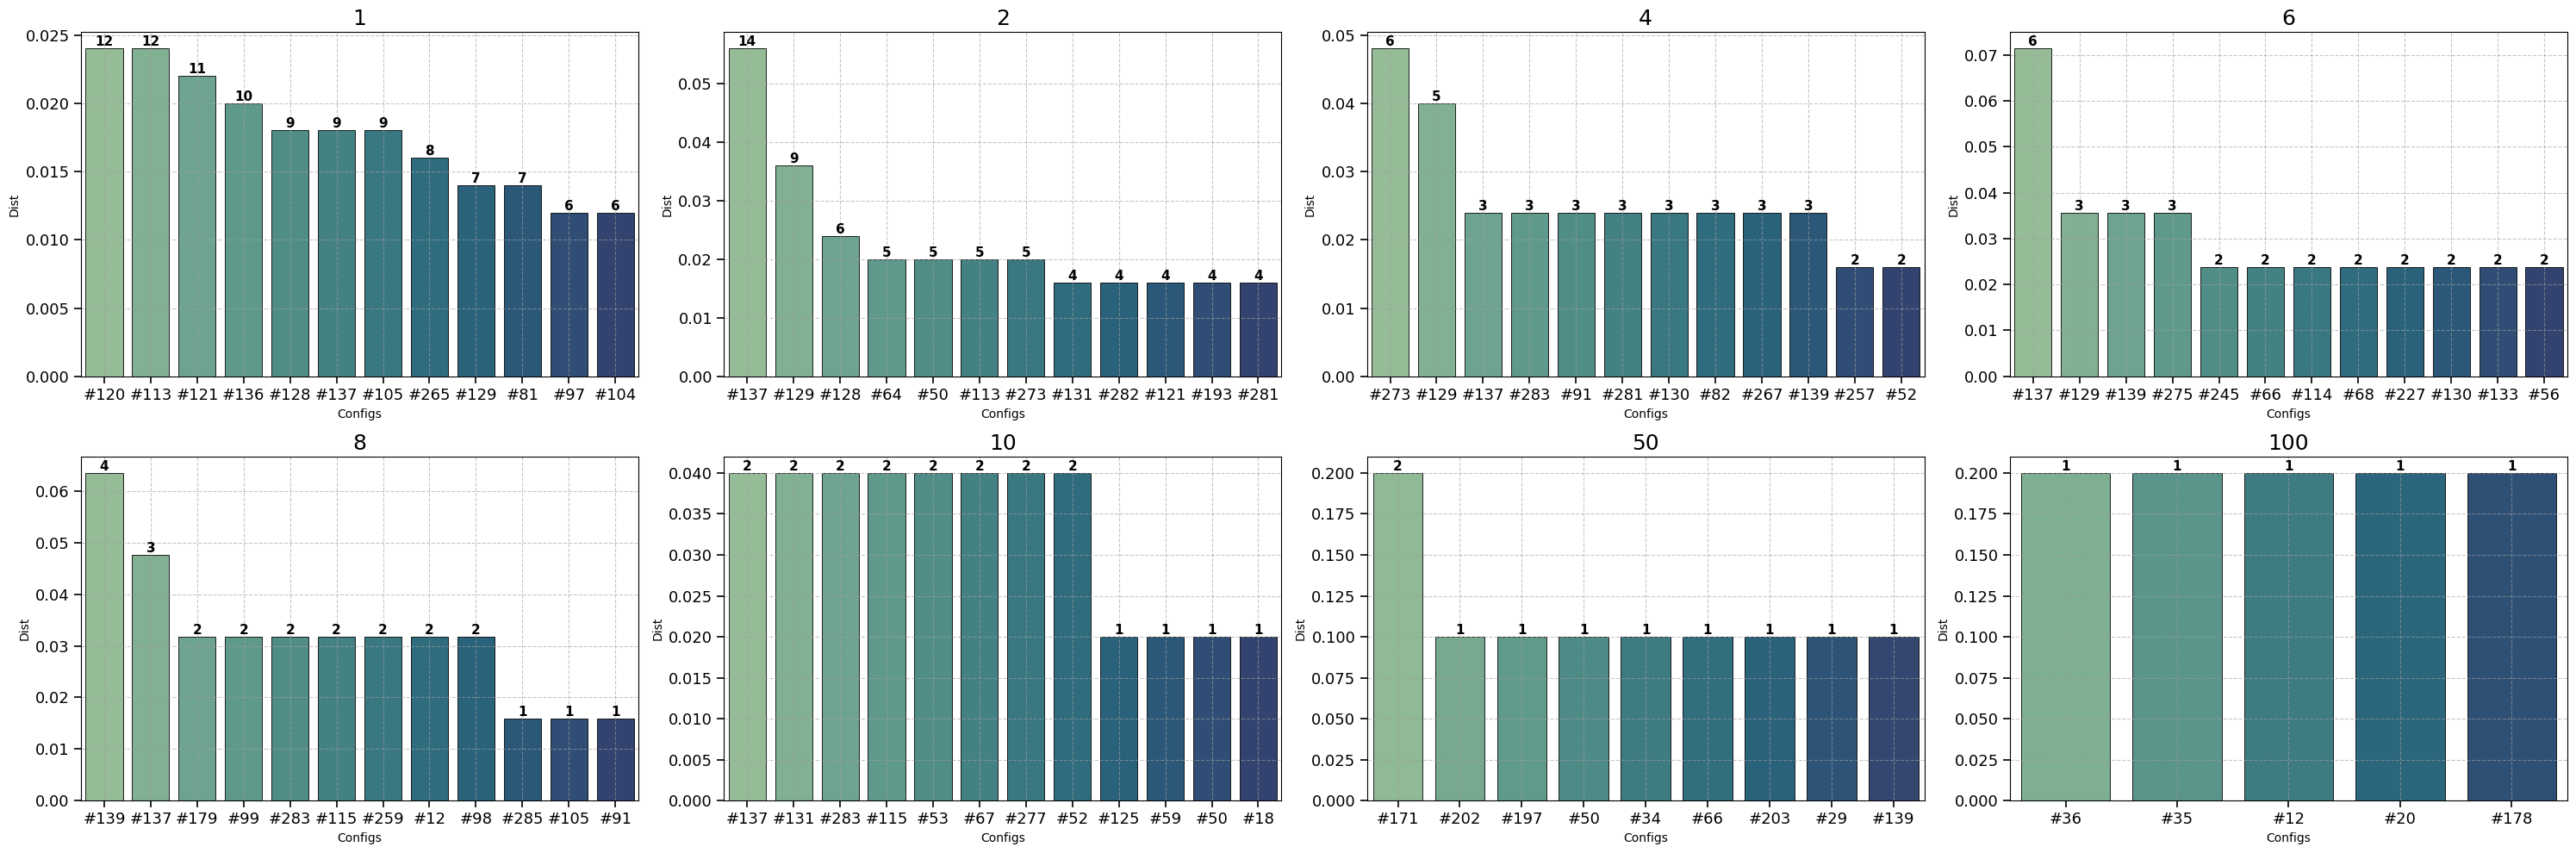

In [8]:
rtr_ms = pd.read_json(base_result / "rtr_query_model_selection.json")
rtr_conf_dist = show_distr_conf(rtr_ms)

In [16]:
rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:120, 2:137, 4:273, 6:137, 8:139, 10:137, 50:171, 100:36},
    "rtr_query_model_selection.json",
    rtr_ms,
    "RuleTreeRank",
    WrapperRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:56<00:00,  8.78it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:45<00:00,  5.53it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [01:23<00:00,  8.32s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [02:30<00:00, 30.12s/it]


Eval


# Mixed RuleTreeRank

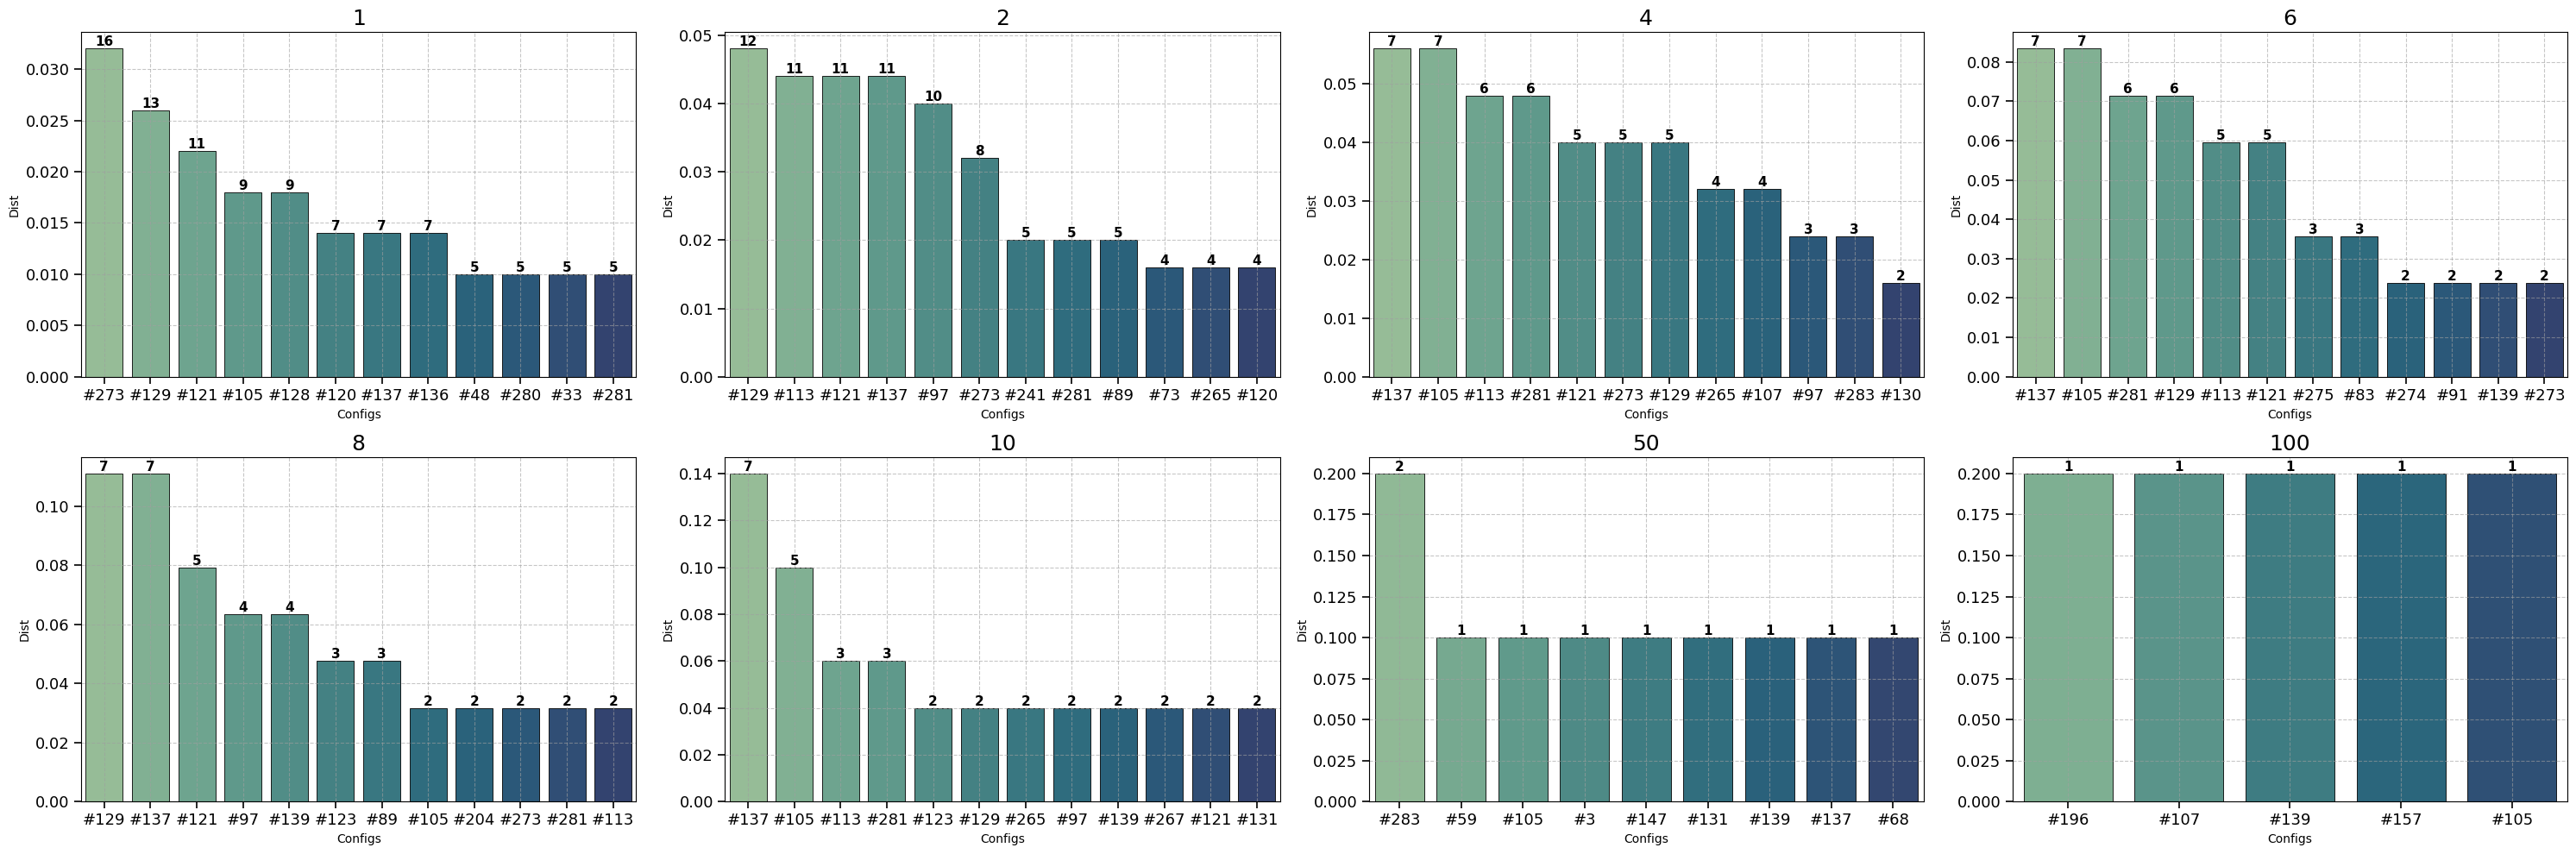

In [6]:
mix_rtr_ms = pd.read_json(base_result / "mix_rtr_query_model_selection.json")
mix_rtr_conf_dist = show_distr_conf(mix_rtr_ms)

In [7]:
mix_rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:273, 2:129, 4:137, 6:137, 8:129, 10:137, 50:287, 100:196},
    "mix_rtr_query_model_selection.json",
    mix_rtr_ms,
    "Mix-RuleTreeRank",
    WrapperMixRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:52<00:00,  9.50it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:29<00:00,  8.42it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [03:30<00:00, 21.02s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:36<00:00,  7.25s/it]


Eval


# Pivot RuleTReeRank

# KNN PDT

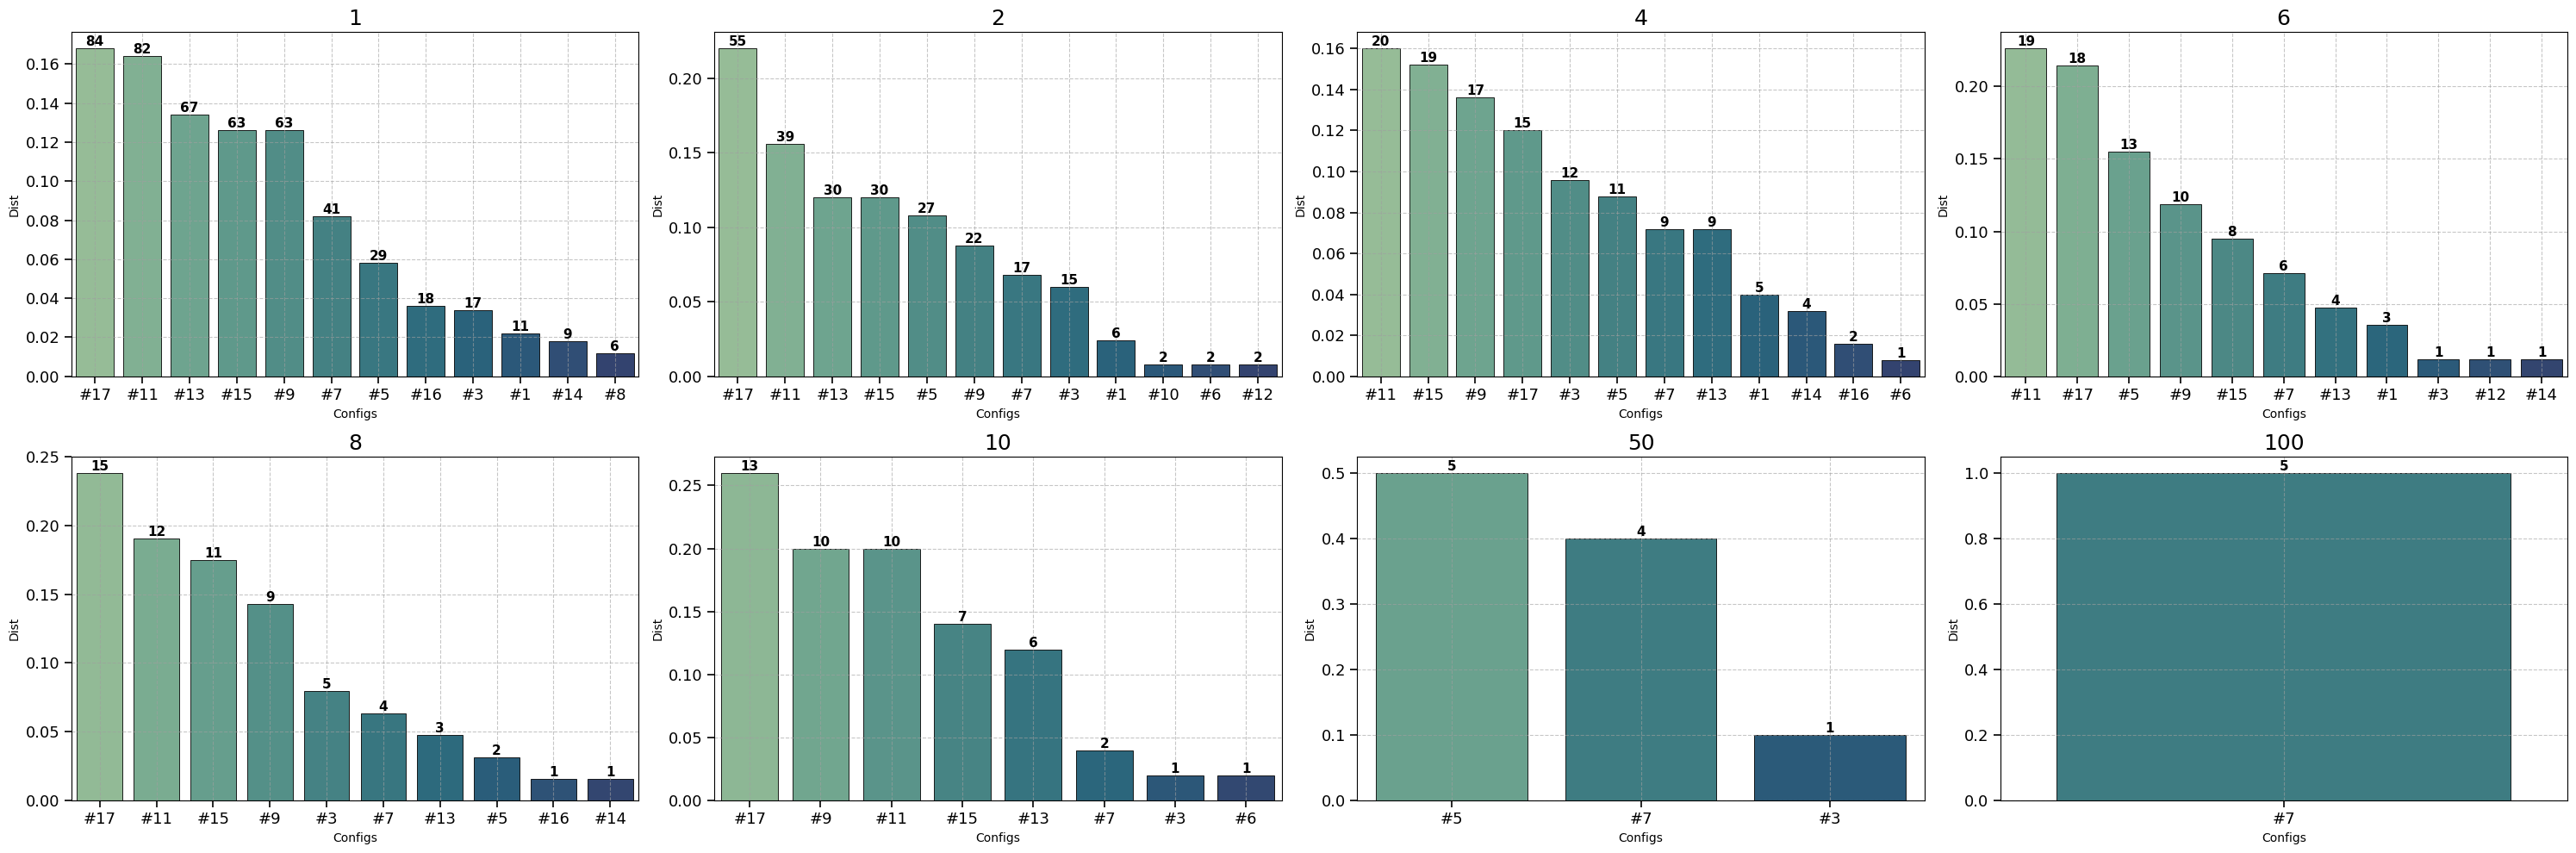

In [8]:
knn_pdt_ms = pd.read_json(base_result / "knn_pdt_query_model_selection.json")
knn_pdt_conf_dist = show_distr_conf(knn_pdt_ms)

In [9]:
knn_pdt_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:17, 2:17, 4:11, 6:11, 8:17, 10:17, 50:5, 100:7},
    "knn_pdt_query_model_selection.json",
    knn_pdt_ms,
    "KNNwPDT",
    WrapperKNNPDT,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:59<00:00,  8.40it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [01:24<00:00,  2.96it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [51:59<00:00, 311.98s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [1:55:30<00:00, 1386.03s/it]


Eval


# Final eval

In [22]:
from ltr_utility.model_selection.retrain import retrain_evaluate

random_result = retrain_evaluate(
    train_valid=train_valid,
    test=test,
    configs={i: (None, {}) for i in [1, 2, 4, 6, 8, 10, 50, 100]},
    model=RandomRanker, name="RandomRanker")

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 7691.48it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 7550.18it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 6144.60it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 3243.35it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 2020.77it/s]


In [ ]:
df_result = pd.concat([
    knn_pdt_result,
    knn_result,
    lm_result,
    mix_rtr_result,
    rtr_result,
    random_result,
], axis=0)


In [24]:
pd.concat([
    results,
    pd.read_json(base_result / "ilmart_query_model_selection.json"),
    pd.read_json(base_result / "listnet_query_model_selection.json"),
], axis=0).to_json(base_result / "MQ2008LIST_result.json", orient="records")

In [10]:
# results = []
# df_result = pd.concat([mix_rtr_result, knn_pdt_result], axis=0)
# for _, row in tqdm(df_result.iterrows(), total=len(df_result)):
#     for k in eval_at:
#         res = evaluate(row["pred_test"], test.y, test.group_count, k=k,
#                        weight=False, aggregated=False)
#         results.append((row["model"], "test", row["qxm"], k, res))
#
# results = pd.DataFrame(results, columns=["model", "fold", "qxm", "k", "ndcg_s"])
# results.to_csv("MQ2008LIST_noagg.csv")

48it [01:16,  1.60s/it]                        
